<a href="https://colab.research.google.com/github/gyeongee/TIL/blob/main/LDA_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

iris = load_iris()
iris_scaled = StandardScaler().fit_transform(iris.data)

In [3]:
# 2개의 component로 붓꽃 데이터를 LDA로 변환
lda = LinearDiscriminantAnalysis(n_components=2)
# 클래스의 결정값이 변환 시에 필요
lda.fit(iris_scaled,iris.target)
iris_lda = lda.transform(iris_scaled)
print(iris_lda.shape)

(150, 2)


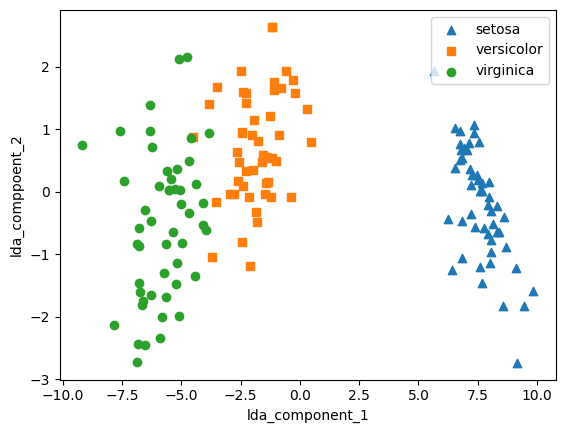

In [4]:
lda_columns=['lda_component_1','lda_component_2']
iris_df_lda = pd.DataFrame(iris_lda,columns=lda_columns)
iris_df_lda['target']=iris.target

# setosa는 세모, versicolor는 네모, virginica는 동그라미로 표현
markers=['^','s','o']

# setosa의 target 값은 0, versicolor는 1, virginica는 2, 각 target 별로 다른 모양으로 산점도로 표시
for i,marker in enumerate(markers):
  x_axis_data = iris_df_lda[iris_df_lda['target']==i]['lda_component_1']
  y_axis_data = iris_df_lda[iris_df_lda['target']==i]['lda_component_2']

  plt.scatter(x_axis_data,y_axis_data,marker=marker,label=iris.target_names[i])

plt.legend(loc='upper right')
plt.xlabel('lda_component_1')
plt.ylabel('lda_comppoent_2')
plt.show()

LDA로 변환된 붓꽃 데이터 세트를 시각화해보면 PCA로 변환된 데이터와 좌우 대칭 형태로 많이 닮아있음을 알 수 있습니다.